# IVF-PQ Benchmark - Semaine 4 Partie A

## Comparatif ANN : Indexation Vectorielle

**Objectif** : Implémenter et analyser **IVF-PQ** (Inverted File with Product Quantization)

**Dataset** : SIFT1M (1 million de vecteurs, 128 dimensions)

**Méthode** : IVF (clustering) + PQ (compression par quantification)

---

### Principe IVF-PQ

1. **IVF** : Partitionne l'espace en `nlist` cellules via K-means
2. **PQ** : Compresse les vecteurs résiduels en codes quantifiés
3. **Recherche** : Visite `nprobe` cellules les plus proches

**Avantage** : Très faible empreinte mémoire

## 1. Installation et Imports

In [1]:
# Installation des dépendances (à exécuter une seule fois)
# !pip install faiss-cpu numpy matplotlib -q

In [2]:
import faiss
import numpy as np
import matplotlib.pyplot as plt
import time
import os
import sys
from typing import Tuple, List, Dict

# Chemins
DATA_PATH = "./sift1m/"
RESULTS_PATH = "./results/"

print(f"FAISS version: {faiss.__version__}")
print(f"NumPy version: {np.__version__}")

FAISS version: 1.13.0
NumPy version: 2.0.2


## 2. Chargement du Dataset SIFT1M

Le dataset SIFT1M contient :
- **Base** : 1M vecteurs (128 dim)
- **Query** : 10k vecteurs de requête
- **Ground Truth** : 100 vrais voisins par requête

In [3]:
def read_fvecs(filename: str) -> np.ndarray:
    """
    Charge un fichier .fvecs (vecteurs float32).
    Format: [dim, v1, v2, ..., v_dim] répété pour chaque vecteur
    """
    with open(filename, 'rb') as f:
        # Lire la dimension
        d = np.fromfile(f, dtype=np.int32, count=1)[0]
        f.seek(0)
        
        # Calculer le nombre de vecteurs
        file_size = os.path.getsize(filename)
        vec_size = 4 + d * 4  # 4 bytes (dim) + d * 4 bytes (floats)
        n_vectors = file_size // vec_size
        
        # Lire tous les vecteurs
        data = np.fromfile(f, dtype=np.int32, count=n_vectors * (d + 1))
        data = data.reshape(-1, d + 1)
        
        # Extraire les vecteurs (ignorer première colonne)
        vectors = data[:, 1:].view(dtype=np.float32)
    
    return vectors

def read_ivecs(filename: str) -> np.ndarray:
    """
    Charge un fichier .ivecs (vecteurs int32).
    """
    with open(filename, 'rb') as f:
        d = np.fromfile(f, dtype=np.int32, count=1)[0]
        f.seek(0)
        
        file_size = os.path.getsize(filename)
        vec_size = 4 + d * 4
        n_vectors = file_size // vec_size
        
        data = np.fromfile(f, dtype=np.int32, count=n_vectors * (d + 1))
        data = data.reshape(-1, d + 1)
        vectors = data[:, 1:]
    
    return vectors

def load_sift1m(data_dir: str = './data') -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Charge le dataset SIFT1M complet.
    """
    print("Chargement du dataset SIFT1M...")
    
    base_file = os.path.join(data_dir, 'sift_base.fvecs')
    query_file = os.path.join(data_dir, 'sift_query.fvecs')
    gt_file = os.path.join(data_dir, 'sift_groundtruth.ivecs')
    
    base_vectors = read_fvecs(base_file)
    query_vectors = read_fvecs(query_file)
    ground_truth = read_ivecs(gt_file)
    
    print(f"  Base vectors: {base_vectors.shape}")
    print(f"  Query vectors: {query_vectors.shape}")
    print(f"  Ground truth: {ground_truth.shape}")
    
    return base_vectors, query_vectors, ground_truth

In [4]:
# Chargement des données SIFT1M
try:
    base_vectors, query_vectors, ground_truth = load_sift1m(DATA_PATH)
except FileNotFoundError:
    raise FileNotFoundError(
        f"Dataset SIFT1M introuvable dans '{DATA_PATH}'.\n"
        "Crée le dossier Valentin/data/ et place-y les fichiers :\n"
        "  - sift_base.fvecs\n"
        "  - sift_query.fvecs\n"
        "  - sift_groundtruth.ivecs\n"
        "Téléchargement : ftp://ftp.irisa.fr/local/texmex/corpus/sift.tar.gz"
    )

Chargement du dataset SIFT1M...
  Base vectors: (1000000, 128)
  Query vectors: (10000, 128)
  Ground truth: (10000, 100)


### Aide rapide: verifier le dataset SIFT1M

## 3. Module de Métriques

Fonctions pour évaluer les performances :
- **Recall@K** : Précision des résultats
- **QPS** : Requêtes par seconde
- **Latence** : Temps par requête (ms)
- **Mémoire** : Taille de l'index

In [5]:
def calculate_recall_at_k(predictions: np.ndarray, ground_truth: np.ndarray, k: int = 10) -> float:
    """
    Calcul du Recall@K.
    
    Args:
        predictions: (n_queries, k) indices prédits
        ground_truth: (n_queries, k_gt) vrais indices
        k: nombre de voisins à considérer
    """
    n_queries = predictions.shape[0]
    recalls = []
    
    for i in range(n_queries):
        pred_set = set(predictions[i, :k])
        true_set = set(ground_truth[i, :k])
        
        intersection = len(pred_set.intersection(true_set))
        recall = intersection / k
        recalls.append(recall)
    
    return np.mean(recalls)

def measure_query_time(index, query_vectors: np.ndarray, k: int = 10, n_runs: int = 3):
    """
    Mesure le temps de requête moyen.
    """
    n_queries = query_vectors.shape[0]
    
    # Warmup
    _, _ = index.search(query_vectors[:100], k)
    
    # Mesure
    times = []
    for _ in range(n_runs):
        start = time.time()
        D, I = index.search(query_vectors, k)
        elapsed = time.time() - start
        times.append(elapsed)
    
    avg_time = np.mean(times)
    qps = n_queries / avg_time
    latency_ms = (avg_time / n_queries) * 1000
    
    return qps, latency_ms, (D, I)

def estimate_index_size(index) -> float:
    """
    Estime la taille mémoire de l'index en Mo.
    """
    if hasattr(index, 'nlist') and hasattr(index, 'pq'):
        d = index.d
        nlist = index.nlist
        m = index.pq.M
        ntotal = index.ntotal
        
        # Taille des centroïdes
        centroids_size = nlist * d * 4
        # Taille des codes PQ
        codes_size = ntotal * m
        # Taille totale
        size_bytes = centroids_size + codes_size
    else:
        size_bytes = sys.getsizeof(index)
    
    size_mb = size_bytes / (1024 * 1024)
    return size_mb

## 4. Création et Entraînement de l'Index IVF-PQ

### Paramètres clés :
- **nlist** : Nombre de cellules Voronoi (ex: 1024)
- **m** : Nombre de sous-quantificateurs (ex: 8, doit diviser 128)
- **nbits** : Bits par code (généralement 8)
- **nprobe** : Cellules visitées lors de la recherche

In [6]:
# Configuration IVF-PQ
d = 128  # dimension des vecteurs SIFT
nlist = 1024  # nombre de cellules Voronoi
m = 8  # sous-quantificateurs (128 / 8 = 16 dim par sous-vecteur)
nbits = 8  # 8 bits = 256 codes par sous-quantificateur

print(f"Configuration IVF-PQ:")
print(f"  - Dimension: {d}")
print(f"  - nlist (cellules): {nlist}")
print(f"  - m (sous-quantificateurs): {m}")
print(f"  - nbits: {nbits}")

Configuration IVF-PQ:
  - Dimension: 128
  - nlist (cellules): 1024
  - m (sous-quantificateurs): 8
  - nbits: 8


In [7]:
# Créer le coarse quantizer (pour la partition IVF)
quantizer = faiss.IndexFlatL2(d)

# Créer l'index IVF-PQ
index_ivfpq = faiss.IndexIVFPQ(quantizer, d, nlist, m, nbits)

print(f"✓ Index IVF-PQ créé")
print(f"  Type: {type(index_ivfpq).__name__}")
print(f"  Is trained: {index_ivfpq.is_trained}")

✓ Index IVF-PQ créé
  Type: IndexIVFPQ
  Is trained: False


In [ ]:
# Entraînement de l'index
# Échantillon aléatoire de 100k vecteurs (reproductible, seed=42)

train_size = 100000
rng = np.random.default_rng(42)
idx_train = rng.choice(base_vectors.shape[0], size=train_size, replace=False)
train_data = base_vectors[idx_train].copy()

print(f"Entraînement sur {train_size} vecteurs (échantillon aléatoire, seed=42)...")
start_time = time.time()

index_ivfpq.train(train_data)

train_time = time.time() - start_time
print(f"✓ Entraînement terminé en {train_time:.2f} secondes")
print(f"  Is trained: {index_ivfpq.is_trained}")

In [9]:
# Ajout des vecteurs de base à l'index

print(f"📥 Ajout de {base_vectors.shape[0]} vecteurs...")
start_time = time.time()

index_ivfpq.add(base_vectors)

add_time = time.time() - start_time
print(f"✓ Vecteurs ajoutés en {add_time:.2f} secondes")
print(f"  Vecteurs indexés: {index_ivfpq.ntotal}")

build_time_total = train_time + add_time
print(f"\n⏱️  Temps total de construction: {build_time_total:.2f} secondes")

📥 Ajout de 1000000 vecteurs...
✓ Vecteurs ajoutés en 1.78 secondes
  Vecteurs indexés: 1000000

⏱️  Temps total de construction: 4.66 secondes


## 5. Benchmark du Paramètre nprobe

**nprobe** contrôle le trade-off précision/vitesse :
- nprobe = 1 : Rapide mais peu précis
- nprobe ↑ : Plus précis mais plus lent

In [10]:
# Tester différentes valeurs de nprobe

nprobe_values = [1, 2, 5, 10, 20, 50, 100, 200]
k = 10  # nombre de voisins à chercher

results_nprobe = []

print(f"📊 Benchmark nprobe (k={k})\n")
print(f"{'nprobe':>8} {'Recall@10':>12} {'Latence(ms)':>14} {'QPS':>10}")
print("="*50)

for nprobe in nprobe_values:
    index_ivfpq.nprobe = nprobe
    
    # Mesurer performances
    qps, latency_ms, (D, I) = measure_query_time(index_ivfpq, query_vectors, k=k)
    
    # Calculer recall
    recall = calculate_recall_at_k(I, ground_truth, k=k)
    
    result = {
        'nprobe': nprobe,
        'recall': recall,
        'qps': qps,
        'latency_ms': latency_ms
    }
    results_nprobe.append(result)
    
    print(f"{nprobe:8d} {recall:12.4f} {latency_ms:14.2f} {qps:10.1f}")

# Mesurer la mémoire (constante pour cet index)
memory_mb = estimate_index_size(index_ivfpq)
print(f"\n💾 Empreinte mémoire: {memory_mb:.2f} Mo")

📊 Benchmark nprobe (k=10)

  nprobe    Recall@10    Latence(ms)        QPS
       1       0.2359           0.00   493501.7
       2       0.2936           0.00   415300.9
       5       0.3470           0.00   284141.9
      10       0.3660           0.01   170770.7
      20       0.3734           0.01   101331.1
      50       0.3755           0.02    46880.9
     100       0.3756           0.04    24535.6
     200       0.3756           0.07    13428.2

💾 Empreinte mémoire: 8.13 Mo


## 6. Visualisations

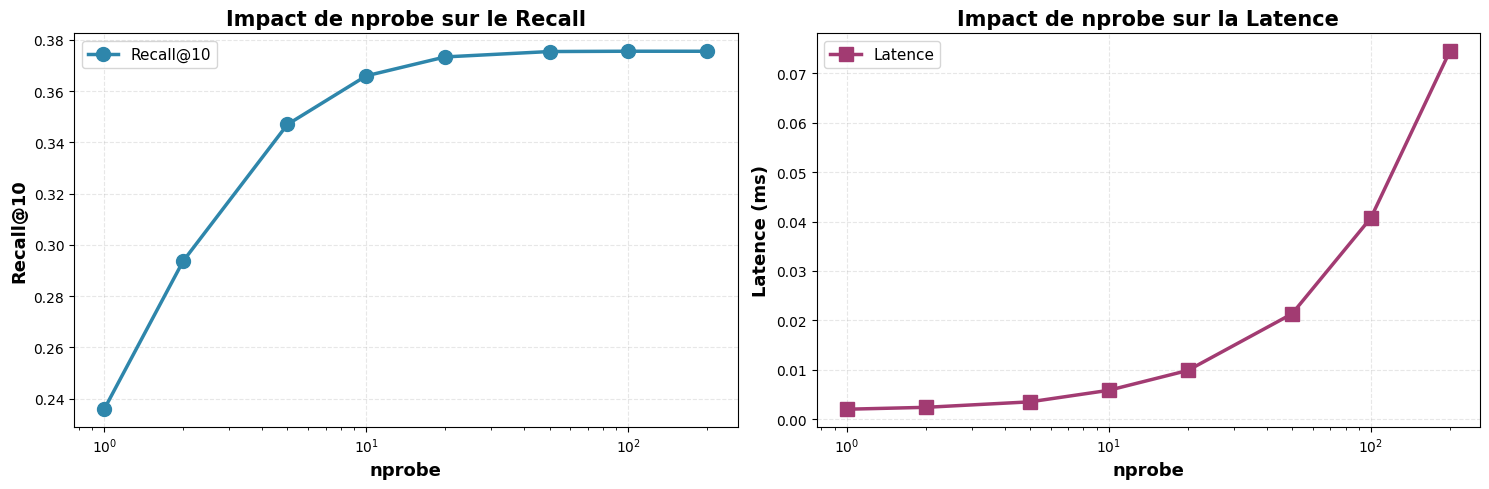

✓ Graphique sauvegardé: ivfpq_nprobe_impact.png


In [11]:
# Graphique 1: Impact de nprobe sur Recall et Latence

nprobe_list = [r['nprobe'] for r in results_nprobe]
recall_list = [r['recall'] for r in results_nprobe]
latency_list = [r['latency_ms'] for r in results_nprobe]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Recall vs nprobe
ax1.plot(nprobe_list, recall_list, 'o-', linewidth=2.5, markersize=10, 
         color='#2E86AB', label='Recall@10')
ax1.set_xlabel('nprobe', fontsize=13, fontweight='bold')
ax1.set_ylabel('Recall@10', fontsize=13, fontweight='bold')
ax1.set_title('Impact de nprobe sur le Recall', fontsize=15, fontweight='bold')
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.set_xscale('log')
ax1.legend(fontsize=11)

# Latence vs nprobe
ax2.plot(nprobe_list, latency_list, 's-', linewidth=2.5, markersize=10, 
         color='#A23B72', label='Latence')
ax2.set_xlabel('nprobe', fontsize=13, fontweight='bold')
ax2.set_ylabel('Latence (ms)', fontsize=13, fontweight='bold')
ax2.set_title('Impact de nprobe sur la Latence', fontsize=15, fontweight='bold')
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.set_xscale('log')
ax2.legend(fontsize=11)

plt.tight_layout()
plt.savefig('ivfpq_nprobe_impact.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Graphique sauvegardé: ivfpq_nprobe_impact.png")

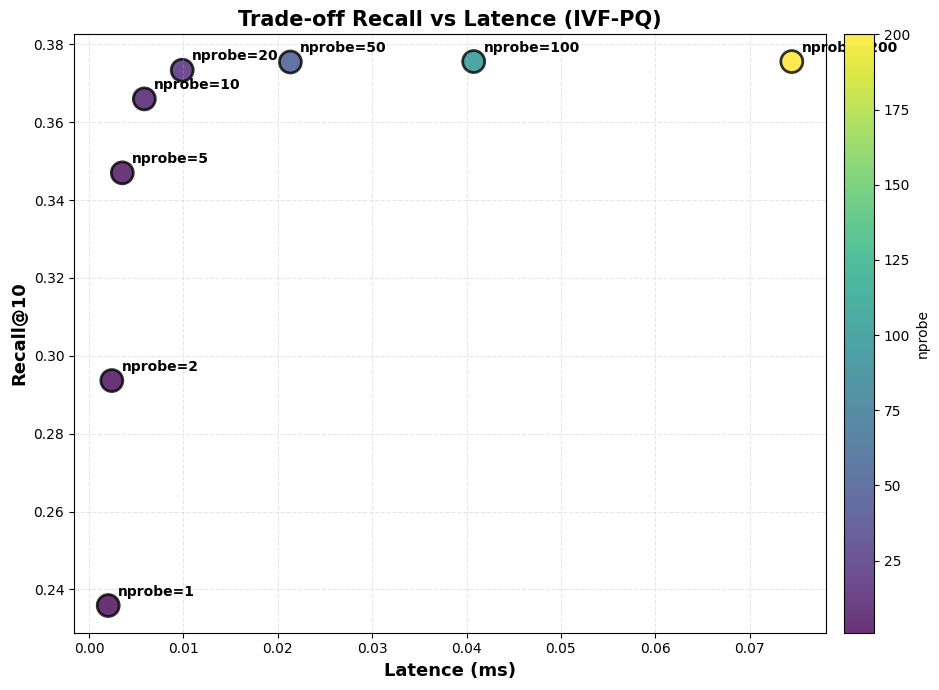

✓ Graphique sauvegardé: ivfpq_recall_latency.png


In [12]:
# Graphique 2: Trade-off Recall vs Latence

plt.figure(figsize=(10, 7))

scatter = plt.scatter(latency_list, recall_list, c=nprobe_list, 
                     cmap='viridis', s=250, alpha=0.8, 
                     edgecolors='black', linewidth=2)

# Annotations
for i, np_val in enumerate(nprobe_list):
    plt.annotate(f'nprobe={np_val}', 
                (latency_list[i], recall_list[i]),
                xytext=(7, 7), textcoords='offset points', 
                fontsize=10, fontweight='bold')

plt.colorbar(scatter, label='nprobe', pad=0.02)
plt.xlabel('Latence (ms)', fontsize=13, fontweight='bold')
plt.ylabel('Recall@10', fontsize=13, fontweight='bold')
plt.title('Trade-off Recall vs Latence (IVF-PQ)', 
         fontsize=15, fontweight='bold')
plt.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('ivfpq_recall_latency.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Graphique sauvegardé: ivfpq_recall_latency.png")

## 7. Comparaison de Différentes Valeurs de nlist

Test de l'impact du nombre de cellules Voronoi

In [13]:
# Tester différentes valeurs de nlist

nlist_values = [256, 512, 1024, 2048]
nprobe_fixed = 10  # valeur fixe de nprobe pour la comparaison

results_nlist = []

print(f"📊 Benchmark nlist (nprobe={nprobe_fixed}, m={m})\n")
print(f"{'nlist':>8} {'Build(s)':>12} {'Recall@10':>12} {'Latence(ms)':>14} {'Memory(Mo)':>13}")
print("="*65)

for nlist_val in nlist_values:
    # Créer nouvel index
    quantizer_temp = faiss.IndexFlatL2(d)
    index_temp = faiss.IndexIVFPQ(quantizer_temp, d, nlist_val, m, nbits)
    
    # Entraîner et ajouter
    start = time.time()
    index_temp.train(train_data)
    index_temp.add(base_vectors)
    build_time = time.time() - start
    
    # Tester avec nprobe fixe
    index_temp.nprobe = nprobe_fixed
    
    qps, latency_ms, (D, I) = measure_query_time(index_temp, query_vectors, k=10)
    recall = calculate_recall_at_k(I, ground_truth, k=10)
    memory = estimate_index_size(index_temp)
    
    result = {
        'nlist': nlist_val,
        'build_time': build_time,
        'recall': recall,
        'latency_ms': latency_ms,
        'memory_mb': memory
    }
    results_nlist.append(result)
    
    print(f"{nlist_val:8d} {build_time:12.2f} {recall:12.4f} {latency_ms:14.2f} {memory:13.2f}")

📊 Benchmark nlist (nprobe=10, m=8)

   nlist     Build(s)    Recall@10    Latence(ms)    Memory(Mo)
     256         3.55       0.3558           0.02          7.75
     512         3.92       0.3628           0.01          7.88
    1024         4.52       0.3660           0.01          8.13
    2048         5.65       0.3635           0.00          8.63


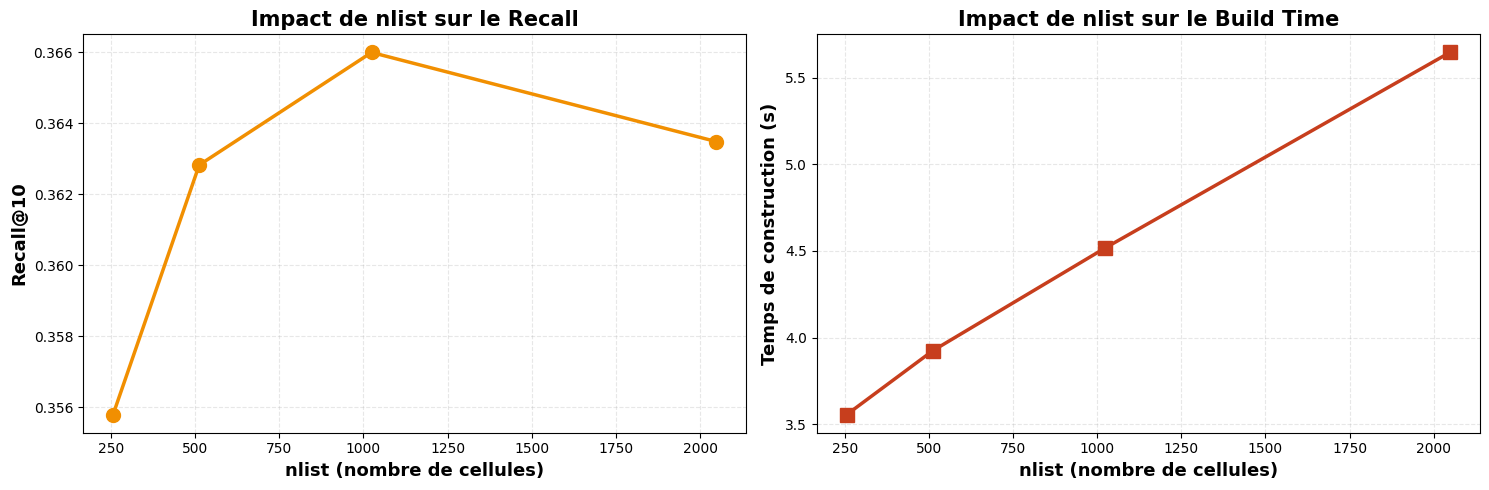

✓ Graphique sauvegardé: ivfpq_nlist_impact.png


In [14]:
# Visualisation impact de nlist

nlist_plot = [r['nlist'] for r in results_nlist]
recall_nlist = [r['recall'] for r in results_nlist]
build_nlist = [r['build_time'] for r in results_nlist]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Recall vs nlist
ax1.plot(nlist_plot, recall_nlist, 'o-', linewidth=2.5, markersize=10, color='#F18F01')
ax1.set_xlabel('nlist (nombre de cellules)', fontsize=13, fontweight='bold')
ax1.set_ylabel('Recall@10', fontsize=13, fontweight='bold')
ax1.set_title('Impact de nlist sur le Recall', fontsize=15, fontweight='bold')
ax1.grid(True, alpha=0.3, linestyle='--')

# Build time vs nlist
ax2.plot(nlist_plot, build_nlist, 's-', linewidth=2.5, markersize=10, color='#C73E1D')
ax2.set_xlabel('nlist (nombre de cellules)', fontsize=13, fontweight='bold')
ax2.set_ylabel('Temps de construction (s)', fontsize=13, fontweight='bold')
ax2.set_title('Impact de nlist sur le Build Time', fontsize=15, fontweight='bold')
ax2.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('ivfpq_nlist_impact.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Graphique sauvegardé: ivfpq_nlist_impact.png")

## 8. Résumé des Résultats

In [15]:
# Résumé final

print("="*70)
print("  RÉSUMÉ FINAL - IVF-PQ BENCHMARK")
print("="*70)

# Meilleur recall
best_recall = max(results_nprobe, key=lambda x: x['recall'])
print(f"\n🏆 Configuration pour meilleur Recall:")
print(f"  nprobe = {best_recall['nprobe']}")
print(f"  Recall@10 = {best_recall['recall']:.4f} ({best_recall['recall']*100:.2f}%)")
print(f"  Latence = {best_recall['latency_ms']:.2f} ms")
print(f"  QPS = {best_recall['qps']:.1f}")

# Meilleure vitesse avec recall > 0.5
fast_results = [r for r in results_nprobe if r['recall'] > 0.5]
if fast_results:
    fastest = min(fast_results, key=lambda x: x['latency_ms'])
    print(f"\n⚡ Configuration la plus rapide (Recall > 50%):")
    print(f"  nprobe = {fastest['nprobe']}")
    print(f"  Recall@10 = {fastest['recall']:.4f} ({fastest['recall']*100:.2f}%)")
    print(f"  Latence = {fastest['latency_ms']:.2f} ms")
    print(f"  QPS = {fastest['qps']:.1f}")

print(f"\n💾 Empreinte mémoire: {memory_mb:.2f} Mo")
print(f"⏱️  Temps de construction: {build_time_total:.2f} secondes")

print(f"\n📁 Fichiers générés:")
print(f"  - ivfpq_nprobe_impact.png")
print(f"  - ivfpq_recall_latency.png")
print(f"  - ivfpq_nlist_impact.png")

print("\n✅ Benchmark IVF-PQ terminé avec succès!")
print("="*70)

  RÉSUMÉ FINAL - IVF-PQ BENCHMARK

🏆 Configuration pour meilleur Recall:
  nprobe = 100
  Recall@10 = 0.3756 (37.56%)
  Latence = 0.04 ms
  QPS = 24535.6

💾 Empreinte mémoire: 8.13 Mo
⏱️  Temps de construction: 4.66 secondes

📁 Fichiers générés:
  - ivfpq_nprobe_impact.png
  - ivfpq_recall_latency.png
  - ivfpq_nlist_impact.png

✅ Benchmark IVF-PQ terminé avec succès!


## 9. Sauvegarde des Résultats en CSV

In [16]:
import pandas as pd

# Sauvegarder résultats nprobe
df_nprobe = pd.DataFrame(results_nprobe)
df_nprobe.to_csv('ivfpq_nprobe_results.csv', index=False)
print("✓ Sauvegardé: ivfpq_nprobe_results.csv")

# Sauvegarder résultats nlist
df_nlist = pd.DataFrame(results_nlist)
df_nlist.to_csv('ivfpq_nlist_results.csv', index=False)
print("✓ Sauvegardé: ivfpq_nlist_results.csv")

# Afficher preview
print("\n📊 Preview résultats nprobe:")
display(df_nprobe)

print("\n📊 Preview résultats nlist:")
display(df_nlist)

✓ Sauvegardé: ivfpq_nprobe_results.csv
✓ Sauvegardé: ivfpq_nlist_results.csv

📊 Preview résultats nprobe:


,nprobe,recall,qps,latency_ms
0,1,0.23585,493501.717836,0.002026
1,2,0.29364,415300.924474,0.002408
2,5,0.34700,284141.911620,0.003519
3,10,0.36599,170770.665186,0.005856
4,20,0.37337,101331.108538,0.009869
5,50,0.37547,46880.877848,0.021331
6,100,0.37559,24535.588161,0.040757
7,200,0.37558,13428.173921,0.074470



📊 Preview résultats nlist:


,nlist,build_time,recall,latency_ms,memory_mb
0,256,3.554716,0.35579,0.015298,7.754395
1,512,3.924097,0.36282,0.009056,7.879395
2,1024,4.517421,0.36599,0.005541,8.129395
3,2048,5.646845,0.36348,0.004354,8.629395


## 10. Observations et Conclusions

### Observations clés :

1. **Impact de nprobe** :
   - ↑ nprobe → ↑ Recall mais ↑ Latence
   - Trade-off clair entre précision et vitesse

2. **Impact de nlist** :
   - Plus de cellules = meilleur partitionnement
   - Mais augmente le temps de construction

3. **Avantages IVF-PQ** :
   - ✅ Très faible empreinte mémoire (compression efficace)
   - ✅ Évolutivité (scalabilité)
   - ✅ Paramétrable (nprobe pour ajuster le trade-off)

4. **Inconvénients** :
   - ⚠️ Nécessite un entraînement (coût initial)
   - ⚠️ Approximation double (IVF + PQ)
   - ⚠️ Recall inférieur à HNSW à vitesse égale

### Recommandations :

- **Utiliser IVF-PQ si** :
  - RAM limitée (contraintes mémoire fortes)
  - Très grande échelle (> 10M vecteurs)
  - Recall modéré acceptable (70-80%)

- **Configuration recommandée** :
  - nlist = 1024 (bon compromis)
  - m = 8 (compression x16)
  - nprobe = 20-50 (selon besoin recall)

### Prochaines étapes (Planning) :

- ✅ Semaine 4 Partie A : IVF-PQ (TERMINÉ)
- 🔜 Semaine 4 Partie B : Implémenter LSH
- 🔜 Semaine 5 : Benchmark tri-méthodes (HNSW vs IVF-PQ vs LSH)
- 🔜 Semaine 6 : Rédaction du rapport final

---

## 11. Compression Uniforme + Test IVF-PQ sur Données Quantifiées puis Reconstruites

### Objectif
Appliquer une **compression lossy uniforme 8 bits par dimension** (float32 → uint8),
puis tester IVF-PQ sur les vecteurs **reconstruits en float32**.

> **Note** : ce benchmark mesure l'impact de la dégradation liée à la quantification
> sur les performances de IVF-PQ, et non une recherche nativement effectuée sur des codes compressés.
> Les méthodes FAISS nécessitent des vecteurs float32 en entrée.

Les données sont sauvegardées dans `../shared_data/` (uint8 et float32) pour être utilisées
par les notebooks LSH (Sedik) et HNSW (chatodit).

### Protocole
- Quantification : float32 → uint8 par dimension (**taux de compression 4x**)
- Reconstruction : uint8 → float32 (pour indexation FAISS)
- Ground truth **recalculée** sur les données reconstruites
- Mêmes hyperparamètres IVF-PQ : `nlist=1024`, `m=8`, `nbits=8`

In [17]:
# ============================================================
# Module de Compression + Génération des données compressées
# + Sauvegarde dans shared_data/ (accès commun LSH & HNSW)
# ============================================================

def fit_uniform_quantizer(vectors: np.ndarray):
    """
    Calcule le min/max par dimension sur base_vectors.
    Plus précis qu'un min/max global car chaque dimension
    peut avoir une plage différente.
    """
    v_min = vectors.min(axis=0).astype(np.float32)  # shape (d,)
    v_max = vectors.max(axis=0).astype(np.float32)  # shape (d,)
    return v_min, v_max

def compress_vectors(vectors: np.ndarray, v_min: np.ndarray, v_max: np.ndarray) -> np.ndarray:
    """float32 → uint8 par quantification uniforme 8 bits (par dimension)."""
    range_ = np.where(v_max - v_min > 0, v_max - v_min, 1.0)  # évite division par zéro
    clipped = np.clip(vectors, v_min, v_max)
    normalized = (clipped - v_min) / range_
    return (normalized * 255).round().astype(np.uint8)

def reconstruct_vectors(quantized: np.ndarray, v_min: np.ndarray, v_max: np.ndarray) -> np.ndarray:
    """uint8 → float32 (reconstruction approchée, par dimension)."""
    range_ = np.where(v_max - v_min > 0, v_max - v_min, 1.0)
    return (quantized.astype(np.float32) / 255.0) * range_ + v_min

# --- Compression ---
print("=== Compression des données SIFT1M (quantification par dimension) ===\n")
v_min, v_max = fit_uniform_quantizer(base_vectors)
print(f"Min moyen par dim: {v_min.mean():.4f}  |  Max moyen par dim: {v_max.mean():.4f}")
print(f"Plage moyenne par dim: {(v_max - v_min).mean():.4f}")

start = time.time()
base_compressed    = compress_vectors(base_vectors, v_min, v_max)
base_reconstructed = reconstruct_vectors(base_compressed, v_min, v_max)
t_compress = time.time() - start

query_compressed    = compress_vectors(query_vectors, v_min, v_max)
query_reconstructed = reconstruct_vectors(query_compressed, v_min, v_max)

ratio_v = base_vectors.nbytes / base_compressed.nbytes
reconstruction_error = np.mean(np.abs(base_vectors[:10000] - base_reconstructed[:10000]))
print(f"\nbase_vectors   : {base_vectors.nbytes / 1024**2:.1f} Mo (float32)")
print(f"base_compressed: {base_compressed.nbytes / 1024**2:.1f} Mo (uint8)")
print(f"Taux de compression : {ratio_v:.1f}x  |  Temps : {t_compress:.2f}s")
print(f"Erreur de reconstruction moyenne : {reconstruction_error:.4f}")

# --- Sauvegarde dans shared_data/ ---
# On sauvegarde les 2 versions :
#   - uint8  : vraie donnée compressée (gain mémoire réel)
#   - float32: données reconstruites pour les méthodes FAISS
SHARED_DATA = "../shared_data/"
os.makedirs(SHARED_DATA, exist_ok=True)

np.save(SHARED_DATA + "base_compressed.npy",    base_compressed)     # uint8
np.save(SHARED_DATA + "query_compressed.npy",   query_compressed)    # uint8
np.save(SHARED_DATA + "base_reconstructed.npy", base_reconstructed)  # float32
np.save(SHARED_DATA + "query_reconstructed.npy",query_reconstructed) # float32
np.save(SHARED_DATA + "compression_params.npy",
        np.stack([v_min, v_max]))  # shape (2, d)

print(f"\nFichiers sauvegardés dans {SHARED_DATA} :")
print(f"  base_compressed.npy     ({base_compressed.nbytes / 1024**2:.1f} Mo — uint8)")
print(f"  query_compressed.npy    ({query_compressed.nbytes / 1024**2:.1f} Mo — uint8)")
print(f"  base_reconstructed.npy  ({base_reconstructed.nbytes / 1024**2:.1f} Mo — float32)")
print(f"  query_reconstructed.npy ({query_reconstructed.nbytes / 1024**2:.1f} Mo — float32)")
print(f"  compression_params.npy  (shape: (2, {v_min.shape[0]}) — [v_min, v_max] par dim)")

=== Compression des données SIFT1M (quantification par dimension) ===

Min moyen par dim: 0.0000  |  Max moyen par dim: 173.0312
Plage moyenne par dim: 173.0312

base_vectors   : 488.3 Mo (float32)
base_compressed: 122.1 Mo (uint8)
Taux de compression : 4.0x  |  Temps : 0.94s
Erreur de reconstruction moyenne : 0.1355

Fichiers sauvegardés dans ../shared_data/ :
  base_compressed.npy     (122.1 Mo — uint8)
  query_compressed.npy    (1.2 Mo — uint8)
  base_reconstructed.npy  (488.3 Mo — float32)
  query_reconstructed.npy (4.9 Mo — float32)
  compression_params.npy  (shape: (2, 128) — [v_min, v_max] par dim)


In [ ]:
# ============================================================
# Recalcul Ground Truth sur données quantifiées puis reconstruites
# ============================================================
print("=== Recalcul Ground Truth (données quantifiées puis reconstruites) ===\n")

K_GT = 100
index_flat_c = faiss.IndexFlatL2(d)
index_flat_c.add(base_reconstructed)

print(f"Calcul des {K_GT} plus proches voisins pour {query_reconstructed.shape[0]} requêtes...")
print("(peut prendre quelques minutes)")

start = time.time()
_, ground_truth_compressed = index_flat_c.search(query_reconstructed, K_GT)
gt_time = time.time() - start

print(f"Ground truth recalculée en {gt_time:.1f} s | shape: {ground_truth_compressed.shape}")
del index_flat_c

In [19]:
# ============================================================
# Test IVF-PQ sur données quantifiées puis reconstruites
# Mêmes hyperparamètres : nlist=1024, m=8, nbits=8
# ============================================================
print("=== IVF-PQ sur données quantifiées puis reconstruites ===\n")
print(f"Hyperparamètres: nlist={nlist}, m={m}, nbits={nbits}")

# Échantillon d'entraînement aléatoire (reproductible)
rng = np.random.default_rng(42)
idx_train = rng.choice(base_reconstructed.shape[0], size=train_size, replace=False)
train_data_compressed = base_reconstructed[idx_train].copy()

quantizer_c = faiss.IndexFlatL2(d)
index_ivfpq_compressed = faiss.IndexIVFPQ(quantizer_c, d, nlist, m, nbits)

print(f"\nEntraînement sur {train_size} vecteurs (échantillon aléatoire, seed=42)...")
start = time.time()
index_ivfpq_compressed.train(train_data_compressed)
train_time_c = time.time() - start
print(f"  Entraînement: {train_time_c:.2f} s")

print(f"Ajout de {base_reconstructed.shape[0]} vecteurs...")
start = time.time()
index_ivfpq_compressed.add(base_reconstructed)
add_time_c = time.time() - start
print(f"  Ajout: {add_time_c:.2f} s")

build_time_c = train_time_c + add_time_c
memory_mb_c = estimate_index_size(index_ivfpq_compressed)
print(f"\nTemps total de construction: {build_time_c:.2f} s")
print(f"Empreinte mémoire index (estimation simplifiée): {memory_mb_c:.2f} Mo")

# Benchmark nprobe — mêmes valeurs que Section 5
results_nprobe_compressed = []

print(f"\n{'nprobe':>8} {'Recall@10':>12} {'Latence(ms)':>14} {'QPS':>10}")
print("="*50)

for nprobe in nprobe_values:
    index_ivfpq_compressed.nprobe = nprobe
    qps_c, latency_c, (D_c, I_c) = measure_query_time(
        index_ivfpq_compressed, query_reconstructed, k=k
    )
    recall_c = calculate_recall_at_k(I_c, ground_truth_compressed, k=k)
    results_nprobe_compressed.append({
        'nprobe': nprobe, 'recall': recall_c,
        'qps': qps_c, 'latency_ms': latency_c
    })
    print(f"{nprobe:8d} {recall_c:12.4f} {latency_c:14.3f} {qps_c:10.1f}")

=== IVF-PQ sur données quantifiées puis reconstruites ===

Hyperparamètres: nlist=1024, m=8, nbits=8

Entraînement sur 100000 vecteurs (échantillon aléatoire, seed=42)...
  Entraînement: 2.83 s
Ajout de 1000000 vecteurs...
  Ajout: 1.68 s

Temps total de construction: 4.51 s
Empreinte mémoire index (estimation simplifiée): 8.13 Mo

  nprobe    Recall@10    Latence(ms)        QPS
       1       0.2392          0.002   493459.1
       2       0.2999          0.002   420130.6
       5       0.3512          0.003   287392.0
      10       0.3701          0.006   166211.5
      20       0.3778          0.010   100269.2
      50       0.3804          0.021    47137.2
     100       0.3805          0.040    25028.1
     200       0.3805          0.078    12802.9


  COMPARAISON IVF-PQ : ORIGINAL vs COMPRESSÉ

Recall et latence par nprobe:


,nprobe,Recall@10 (orig),Recall@10 (comp),Delta Recall,Latence orig (ms),Latence comp (ms),QPS orig,QPS comp
0,1,0.2358,0.2392,0.0033,0.002,0.002,493502.0,493459.0
1,2,0.2936,0.2999,0.0063,0.002,0.002,415301.0,420131.0
2,5,0.3470,0.3512,0.0042,0.004,0.003,284142.0,287392.0
3,10,0.3660,0.3701,0.0041,0.006,0.006,170771.0,166212.0
4,20,0.3734,0.3778,0.0045,0.010,0.010,101331.0,100269.0
5,50,0.3755,0.3804,0.0049,0.021,0.021,46881.0,47137.0
6,100,0.3756,0.3805,0.0049,0.041,0.040,24536.0,25028.0
7,200,0.3756,0.3805,0.0050,0.074,0.078,13428.0,12803.0



  MÉTRIQUES GLOBALES (nprobe=10)


,Métrique,Original,Compressé
0,Build time (s),4.66,4.51
1,Mémoire index (Mo),8.13,8.13
2,Taille vecteurs (Mo),488.3,122.1
3,Taux compression,1x (référence),4.0x
4,Recall@10,0.366,0.3701
5,Latence (ms),0.006,0.006
6,QPS,170771.0,166212.0



CSV sauvegardés: ivfpq_compression_comparison_nprobe.csv, ivfpq_compression_summary.csv


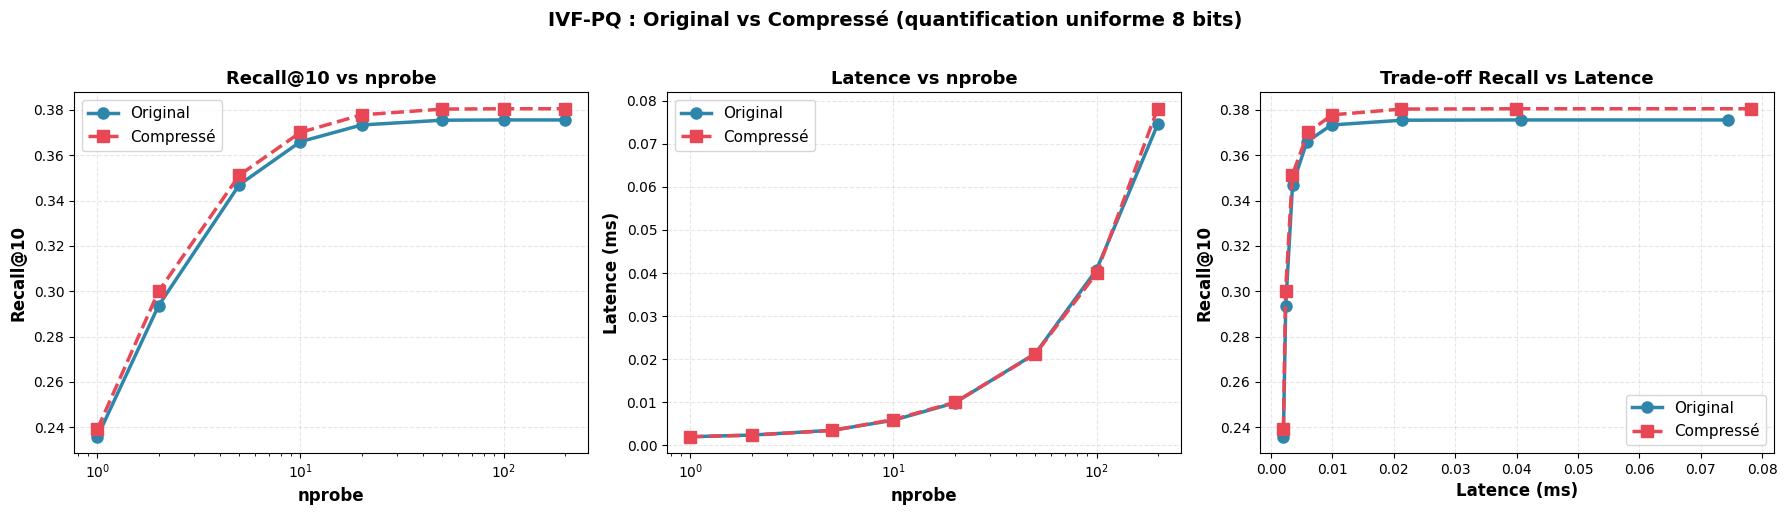

Graphique sauvegardé: ivfpq_compression_comparison.png


In [20]:
import pandas as pd

# ============================================================
# Comparaison finale : Original vs Compressé
# ============================================================
print("="*80)
print("  COMPARAISON IVF-PQ : ORIGINAL vs COMPRESSÉ")
print("="*80)

rows = []
for r_orig, r_comp in zip(results_nprobe, results_nprobe_compressed):
    rows.append({
        'nprobe': r_orig['nprobe'],
        'Recall@10 (orig)': round(r_orig['recall'], 4),
        'Recall@10 (comp)': round(r_comp['recall'], 4),
        'Delta Recall': round(r_comp['recall'] - r_orig['recall'], 4),
        'Latence orig (ms)': round(r_orig['latency_ms'], 3),
        'Latence comp (ms)': round(r_comp['latency_ms'], 3),
        'QPS orig': round(r_orig['qps'], 0),
        'QPS comp': round(r_comp['qps'], 0),
    })

df_comparison = pd.DataFrame(rows)
print("\nRecall et latence par nprobe:")
display(df_comparison)

# Métriques globales
print("\n" + "="*80)
print("  MÉTRIQUES GLOBALES (nprobe=10)")
print("="*80)

ratio_v = base_vectors.nbytes / base_compressed.nbytes
summary = {
    'Métrique': ['Build time (s)', 'Mémoire index (Mo)', 'Taille vecteurs (Mo)',
                 'Taux compression', 'Recall@10', 'Latence (ms)', 'QPS'],
    'Original': [
        round(build_time_total, 2), round(memory_mb, 2),
        round(base_vectors.nbytes / 1024**2, 1), '1x (référence)',
        round(results_nprobe[3]['recall'], 4),
        round(results_nprobe[3]['latency_ms'], 3),
        round(results_nprobe[3]['qps'], 0),
    ],
    'Compressé': [
        round(build_time_c, 2), round(memory_mb_c, 2),
        round(base_compressed.nbytes / 1024**2, 1), f'{ratio_v:.1f}x',
        round(results_nprobe_compressed[3]['recall'], 4),
        round(results_nprobe_compressed[3]['latency_ms'], 3),
        round(results_nprobe_compressed[3]['qps'], 0),
    ]
}
df_summary = pd.DataFrame(summary)
display(df_summary)

df_comparison.to_csv('ivfpq_compression_comparison_nprobe.csv', index=False)
df_summary.to_csv('ivfpq_compression_summary.csv', index=False)
print("\nCSV sauvegardés: ivfpq_compression_comparison_nprobe.csv, ivfpq_compression_summary.csv")

# Visualisation
nprobe_list_c  = [r['nprobe']     for r in results_nprobe_compressed]
recall_list_c  = [r['recall']     for r in results_nprobe_compressed]
latency_list_c = [r['latency_ms'] for r in results_nprobe_compressed]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(nprobe_list, recall_list, 'o-', lw=2.5, ms=8, color='#2E86AB', label='Original')
axes[0].plot(nprobe_list_c, recall_list_c, 's--', lw=2.5, ms=8, color='#E84855', label='Compressé')
axes[0].set_xlabel('nprobe', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Recall@10', fontsize=12, fontweight='bold')
axes[0].set_title('Recall@10 vs nprobe', fontsize=13, fontweight='bold')
axes[0].set_xscale('log')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3, linestyle='--')

axes[1].plot(nprobe_list, latency_list, 'o-', lw=2.5, ms=8, color='#2E86AB', label='Original')
axes[1].plot(nprobe_list_c, latency_list_c, 's--', lw=2.5, ms=8, color='#E84855', label='Compressé')
axes[1].set_xlabel('nprobe', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Latence (ms)', fontsize=12, fontweight='bold')
axes[1].set_title('Latence vs nprobe', fontsize=13, fontweight='bold')
axes[1].set_xscale('log')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3, linestyle='--')

axes[2].plot(latency_list, recall_list, 'o-', lw=2.5, ms=8, color='#2E86AB', label='Original')
axes[2].plot(latency_list_c, recall_list_c, 's--', lw=2.5, ms=8, color='#E84855', label='Compressé')
axes[2].set_xlabel('Latence (ms)', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Recall@10', fontsize=12, fontweight='bold')
axes[2].set_title('Trade-off Recall vs Latence', fontsize=13, fontweight='bold')
axes[2].legend(fontsize=11)
axes[2].grid(True, alpha=0.3, linestyle='--')

plt.suptitle('IVF-PQ : Original vs Compressé (quantification uniforme 8 bits)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('ivfpq_compression_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("Graphique sauvegardé: ivfpq_compression_comparison.png")